# **MÓDULO 33 - Projeto Final de Modelos Avançados**

# Exploração de Dados

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# Visualizar dados
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
# Informações gerais

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [16]:
# Verificar valores nulos

df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


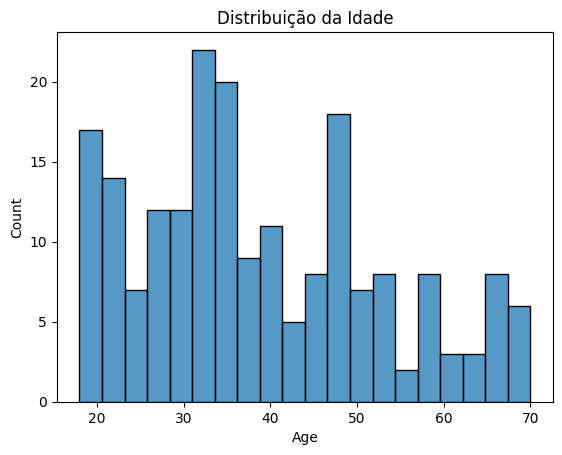

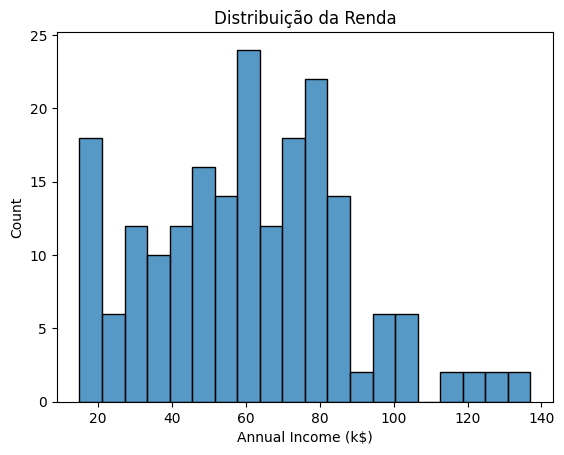

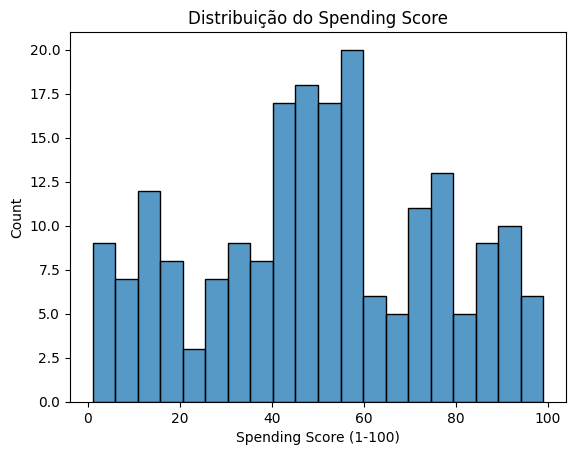

In [17]:
# Distribuição das variáveis

sns.histplot(df['Age'], bins=20)
plt.title('Distribuição da Idade')
plt.show()

sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title('Distribuição da Renda')
plt.show()

sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title('Distribuição do Spending Score')
plt.show()

## Análise de relacionamento entre variáveis

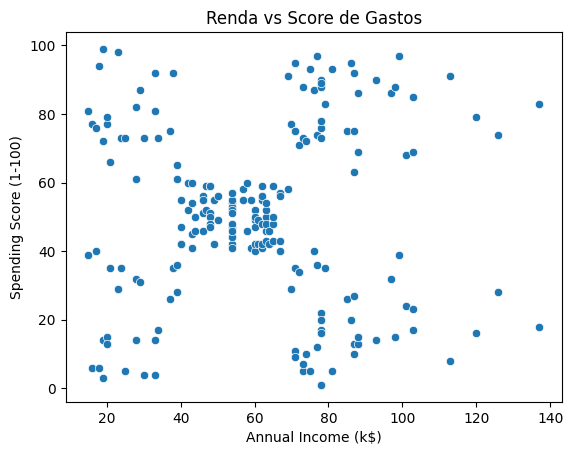

In [22]:
# Análise de relacionamento entre variáveis
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title('Renda vs Score de Gastos')
plt.show()

- A análise Exploratória de Dados do  dataset contendo 200 clientes de um shopping, contendo as variáveis CustomerID, Gender, Age, Annual Income (k$) e Spending Score (1-100). Mostrou que o conjunto de dados possui quatro variáveis numéricas e uma categórica (Gender), e não apresenta valores ausentes, indicando que os dados estão completos e prontos para análise.

- A análise descritiva mostrou que a idade média dos clientes é de aproximadamente 39 anos, variando entre 18 e 70 anos. A renda anual média é de cerca de 60 mil dólares, com valores entre 15 e 137 mil dólares, enquanto o Spending Score possui média próxima de 50, com ampla variação entre 1 e 99. Observou-se maior concentração de clientes com renda entre 50 e 60 mil dólares e Spending Score entre 60 e 70 pontos.


---


De modo geral, as variáveis apresentam boa dispersão e variabilidade, permitindo identificar possíveis grupos de clientes com diferentes perfis de renda e comportamento de gastos. Assim, conclui-se que o dataset está adequado para aplicação do algoritmo K-Means, possibilitando a segmentação de clientes em diferentes clusters para análises futuras.

# Tratamento dos Dados

In [19]:
# Limpar espaços e padronizar texto
df['Gender'] = df['Gender'].str.strip()
df['Gender'] = df['Gender'].str.capitalize()

# Converter a variável Gender
df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

# Verificar se ainda existe NaN
print(df.isnull().sum())

# Remover CustomerID
df = df.drop('CustomerID', axis=1)

# Padronizar os dados
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(
    df_scaled,
    columns=df.columns
)

# Conferir novamente
print(df_scaled.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Após a preparação dos dados, a variável CustomerID foi removida por ser apenas um identificador e não contribuir para a formação dos clusters. A variável Gender foi convertida para valores numéricos, permitindo sua utilização no modelo. Em seguida, foi realizada a padronização das variáveis utilizando StandardScaler, garantindo que todas estivessem na mesma escala e evitando influência indevida nos cálculos de distância do algoritmo K-Means.Após a preparação dos dados, a variável CustomerID foi removida por ser apenas um identificador, e a variável Gender foi convertida para valores numéricos para permitir seu uso no modelo. Em seguida, foi realizada a padronização das variáveis utilizando StandardScaler, garantindo que todas estivessem na mesma escala e evitando influência indevida nos cálculos de distância do algoritmo K-Means.

# Implementação do Algoritmo K-Means



In [62]:
from sklearn.cluster import KMeans

# Aplicar K-Means com k=5
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(df_scaled)

# Adicionar clusters ao dataframe original
df['Cluster'] = clusters

# Visualizar primeiras linhas
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,4
4,1,31,17,40,4


# Avaliação e Interpretação dos Resultados:

In [63]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 20):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(k, score)

2 0.25181529157884364
3 0.25951265087431563
4 0.2983972818544038
5 0.3040600988258827
6 0.33107393337175933
7 0.3573771582429211
8 0.3879927454351689
9 0.4030916511655521
10 0.42076374869477745
11 0.42750694213514717
12 0.4237772982551958
13 0.4175017016951063
14 0.4322212777499121
15 0.42359936447320534
16 0.41440553302244143
17 0.4155773521664842
18 0.39316386722844476
19 0.4101395002959815


In [57]:
# Médias por cluster
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)

         Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                               
0           0.0  58.350000           54.300000               49.150000
1           0.0  24.812500           33.687500               67.500000
2           1.0  35.500000           25.000000               24.125000
3           1.0  32.190476           86.047619               81.666667
4           1.0  53.720000           54.880000               49.520000
5           0.0  45.000000           84.066667               15.400000
6           1.0  27.960000           57.360000               47.120000
7           0.0  33.933333           80.266667               84.200000
8           1.0  25.461538           25.692308               80.538462
9           1.0  43.785714           93.285714               20.642857
10          0.0  52.000000           25.875000               17.250000
11          0.0  30.500000          125.250000               60.750000
12    

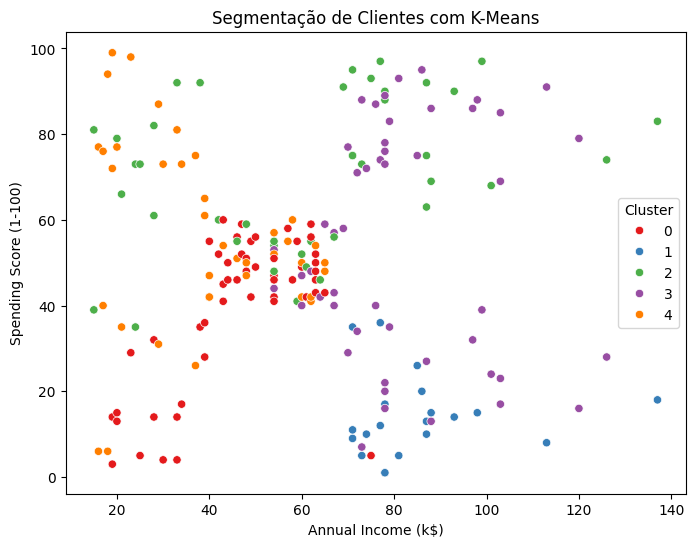

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1'
)

plt.title('Segmentação de Clientes com K-Means')

plt.show()

A aplicação do algoritmo K-Means com k = 5 permitiu identificar cinco perfis distintos de clientes com base em idade, renda e comportamento de gastos. Os clusters apresentaram características variadas, incluindo clientes com alta renda e baixo gasto, clientes jovens com alto consumo e clientes com renda média e comportamento moderado. Essa segmentação permite que empresas desenvolvam estratégias de marketing direcionadas, personalizem ofertas e otimizem a experiência dos clientes, contribuindo para melhores resultados comerciais.

In [66]:
# Aplicar K-Means com k=5
kmeans = KMeans(
    n_clusters=14,
    random_state=42
)

clusters = kmeans.fit_predict(df_scaled)

# Adicionar clusters ao dataframe original
df['Cluster'] = clusters

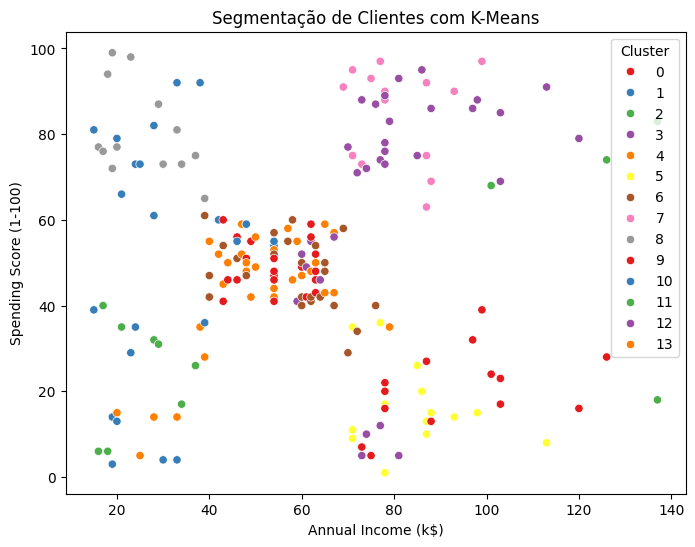

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1'
)

plt.title('Segmentação de Clientes com K-Means')

plt.show()

A aplicação do algoritmo K-Means foi avaliada por meio do Silhouette Score, que mede a qualidade da separação entre os clusters. Foram testados diferentes valores de K entre 2 e 19, sendo observado um aumento progressivo da métrica até atingir um valor máximo de aproximadamente 0,43 com K = 14, indicando uma separação moderada entre os grupos. Apesar disso, valores próximos também foram obtidos para K entre 9 e 11, sugerindo um ponto de estabilidade e melhor equilíbrio entre desempenho e interpretabilidade.

Com base na análise dos clusters, foram identificados diferentes perfis de clientes com comportamentos distintos em relação à idade, renda anual e score de gastos. Entre os principais perfis, destacam-se clientes com alta renda e baixo consumo, indicando baixo engajamento com compras; clientes jovens com alto nível de gastos, representando consumidores mais impulsivos ou ativos; e clientes com renda e consumo moderados, caracterizando um perfil mais equilibrado. Também foram observados grupos com maior idade e comportamento de consumo mais conservador, além de segmentos com padrões intermediários de renda e gasto.

Essa segmentação permite uma compreensão mais clara da base de clientes e pode ser aplicada diretamente em estratégias de negócio. Entre as aplicações práticas, destacam-se campanhas de marketing direcionadas para aumentar o engajamento de clientes com alto poder aquisitivo e baixo consumo, ações promocionais voltadas para clientes jovens com alto gasto, além da personalização de ofertas para diferentes perfis de consumo. Dessa forma, a clusterização contribui para a otimização de estratégias comerciais, aumento da retenção de clientes e melhoria da experiência do usuário.